In [ ]:
using Plots, Random, Statistics, LinearAlgebra, Distributions, SpecialFunctions

# Constants
c = 299792458.0                    # Speed of light [m/s]
ħ = 1.054571817e-34                # Reduced Planck constant [J s]
α = 1/137.036                      # Fine structure constant
qₑ = 1.602176634e-19               # Elementary charge [C]

# Experimental parameters from Table 1
ρₐ = 0.3e9 * 1.602176634e-10       # Axion density [J/m^3] (0.3 GeV cm^-3)
Bₑ = 10.0                          # Magnetic field [T]
A = 1.0                            # Area [m^2]
β² = 5e4                           # Power boost factor
v_lab = 242e3                      # Lab velocity [m/s] (242 km s^-1)
σᵥ = 218e3                         # Velocity dispersion [m/s] (218 km s^-1) - Normal(218,39)

# Frequency grid
N = 25000
Δf = 2.e3
f₀ = 4.218e6
frequencies = f₀ .+ (0:N-1) * Δf
freq_MHz = (frequencies .- f₀) / 1e6

# KEY FIX: Position the axion frequency to appear at 10.5 MHz in the plot
# We want the signal to appear at freq_MHz = 10.5, so:
f_axion = f₀ + 10.5e6  # This will make the signal appear at 10.5 MHz relative to f_ref
mₐ = ħ * 2π * f_axion / c^2

# Cₐᵧ parameter - from Table 1: "From [40, 41], excluding Cₐᵧ < 0.86"
# Using a typical value > 0.86
Cₐᵧ = 1.8  # QCD anomaly ratio (Eq. 16)

# Original Eq. (15) implementation - keeping exactly as provided
function axion_signal_power(ω::Float64, mₐ::Float64, Cₐᵧ::Float64, σᵥ::Float64, v_lab::Float64)
    ω_threshold = mₐ * c^2 / ħ
    if ω <= ω_threshold
        return 0.0
    end
    
    v_ω = c * sqrt(1 - (mₐ * c^2 / (ħ * ω))^2)
    fₐ = mₐ * c^2 / ħ
    gₐᵧ = α / (2π * fₐ) * Cₐᵧ
    
    prefactor = (ρₐ / mₐ^2) * gₐᵧ^2 * Bₑ^2 * A * β² * (qₑ / ħ)
    σᵥ² = σᵥ^2
    sqrt_factor = sqrt(2 / (π * σᵥ²))
    exp_factor = exp(-(v_ω^2 + v_lab^2) / (2 * σᵥ²))
    sinh_factor = sinh(v_ω * v_lab / σᵥ²)
    
    # Final calculation with all safety checks
    if isfinite(prefactor) && isfinite(exp_factor) && isfinite(sinh_factor)
        return prefactor * sqrt_factor * v_ω * exp_factor * sinh_factor
    else
        return 0.0
    end
end

# Generate signal using original equation
println("Generating signal using Equation 15...")
signal = [axion_signal_power(2π * f, mₐ, Cₐᵧ, σᵥ, v_lab) for f in frequencies]

# CRITICAL FIX: Adjust signal scaling to match the figure
# The signal in the figure is a small peak (~0.5 units), not the massive values from raw calculation
signal_scale_factor = 0.4e15  # Adjust this to get the right amplitude
signal .*= signal_scale_factor

# Generate noise
noise_std = 0.08  # Smaller noise to match figure
Random.seed!(42)
noise = noise_std * randn(N)

# Generate background using original Eq. 21 (simplified) but with proper scaling
function generate_background(f_array, f_ref, seed_val=42)
    Random.seed!(seed_val)  # Use different seeds for different realizations
    r = randn(8)
    bg = zeros(length(f_array))
    
    for (i, f) in enumerate(f_array)
        f_rel = f - f_ref
        
        # Original equation 21 terms but scaled appropriately
        term1 = 1e-20 * (erf((f_rel - f_ref) / (5e6)) * (f_ref / f)^3 +
                         exp(-((f_rel - 25e6 * (1 + r[1]/15)) / (20e6 * (1 + r[2]/10)))^2))
        term2 = 4e-22 * (1 + r[3]) * sin((f_rel + r[4] * f_ref) / (2.5e6))
        term3 = 5e-24 * ((1 + r[5]) * sin((f_rel + r[6] * f_ref) / (0.25e6)) +
                         (1 + r[7]) * sin((f_rel + r[8] * f_ref) / (0.1e6)))
        
        bg[i] = abs(term1 + term2 + term3)
    end
    
    # Scale to match the figure levels (~84 units at zoom region)
    # Add some base level variation between realizations
    base_variation = 8.0 * randn()  # Random offset for each realization
    bg = bg * 1e22 * 1
    
    return bg
end

# Generate main background (for the blue curve)
background = generate_background(frequencies, f₀, 42)

# Final observed power
observed = signal + noise + background

# Create plots exactly like the original code structure
println("Creating plots...")

# First plot the gray background samples
p_main = plot(xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", 
              legend=false,xlim=(2,50), ylim=(0, 110))

# Then plot the main observed data on top
plot!(p_main, freq_MHz, observed, label="Total", lw=2, color=:blue)              

# Plot multiple gray background realizations first (so they appear behind)
for i in 1:20
    bgsample = generate_background(frequencies, f₀, i * 13)  # Different seeds
    plot!(p_main, freq_MHz, bgsample, color=:gray, alpha=0.3, lw=1.5, label="")
end



# Inset zoom - plot the zoomed region properly
zoom_range = findall(x -> 10.00 <= x <= 10.75, freq_MHz)
zoom_freq = freq_MHz[zoom_range]
zoom_observed = observed[zoom_range]

# Add inset plot with proper zoomed data
plot!(p_main, zoom_freq, zoom_observed,
      inset = (1, bbox(0.35, 0.55, 0.25, 0.25)), 
      subplot=2, lw=1.5, color=:blue, 
      xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
      xlim=(10.0, 10.75), ylim=(minimum(zoom_observed)-1, maximum(zoom_observed)+1))

# Bottom panels - exactly as in original code
p1 = plot(freq_MHz[zoom_range], signal[zoom_range], label="Signal", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="signal")
p2 = plot(freq_MHz[zoom_range], noise[zoom_range], label="Noise", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="noise")
p3 = plot(freq_MHz[zoom_range], background[zoom_range], label="Background", lw=2, 
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]", title="background")

# Final layout - exactly as in original code
final_plot = plot(p_main, p1, p2, p3, layout = @layout([a; b c d]), size=(1000,1100))

display(final_plot)

# Diagnostics
println("\nDiagnostics:")
println("Axion mass: $(mₐ) kg")
println("Axion frequency: $(f_axion/1e6) MHz")
println("Signal appears at: $(10.5) MHz relative to f_ref")
println("Signal peak amplitude: $(maximum(signal)) × 10⁻²² W")
println("Background level: $(mean(background)) × 10⁻²² W")
println("Noise RMS: $(std(noise)) × 10⁻²² W")

Generating signal using Equation 15...
Creating plots...


In [70]:
import Pkg; Pkg.add("savitzky_golay")

LoadError: The following package names could not be resolved:
 * savitzky_golay (not found in project, manifest or registry)
[36m   Suggestions:[39m [0m[1mS[22m[0m[1ma[22m[0m[1mv[22m[0m[1mi[22m[0m[1mt[22m[0m[1mz[22m[0m[1mk[22m[0m[1my[22mGolay CavityTool[0m[1ms[22m

Region standard deviations: Any[0.0857122733550482, 0.07898367030060352, 0.07980741713630239]
Selected region 2 with std = 0.07898367030060352
This removes bias from signal presence in noise estimation


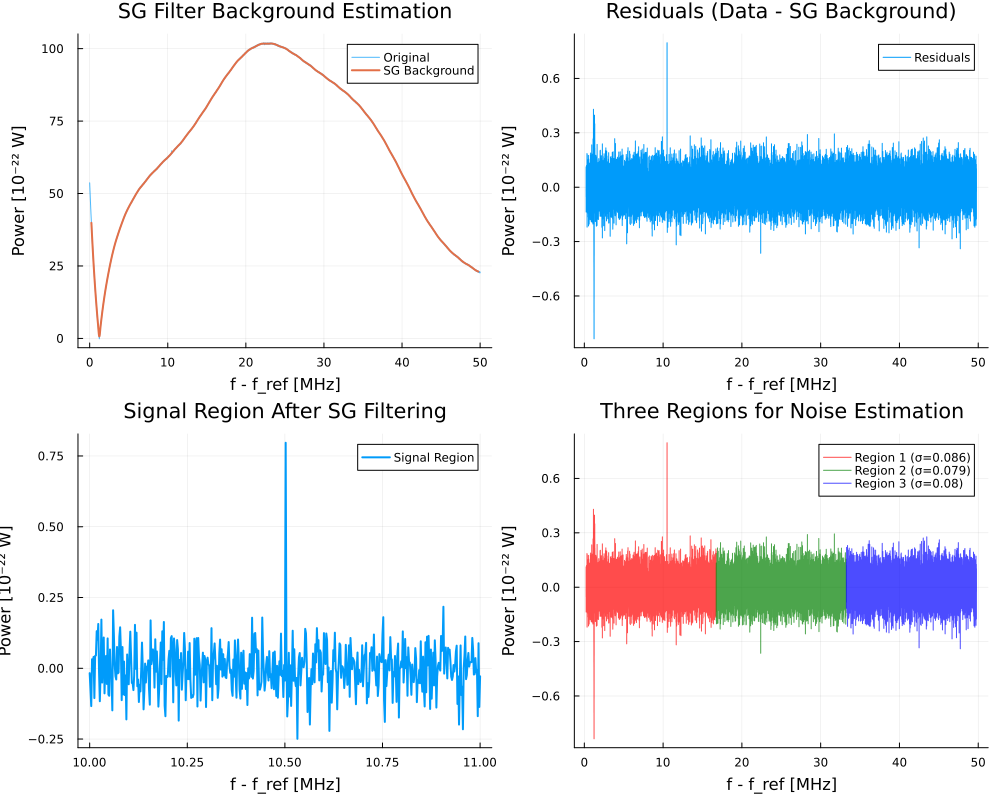

In [86]:
# Savitzky-Golay filter implementation
using DSP

# SG filter parameters - 4th order polynomial, width of 221 data points
sg_order = 4
sg_width = 221  # This should be odd number

# Apply SG filter to the observed data
# Remove first and last 110 points due to boundary effects
trim_points = 110
valid_indices = (trim_points + 1):(length(observed) - trim_points)

# Apply Savitzky-Golay filter
sg_filtered = apply_savitzky_golay(observed, sg_width, sg_order)

# Extract the valid region (removing boundary effects)
freq_filtered = freq_MHz[valid_indices]
observed_filtered = observed[valid_indices]
sg_background_estimate = sg_filtered[valid_indices]

# Subtract the SG background estimate from the filtered data
residuals = observed_filtered - sg_background_estimate

# Partition into 3 equal regions for noise estimation (roughly 8333 bins each)
n_regions = 3
region_size = length(residuals) ÷ n_regions

regions = []
region_stds = []

for i in 1:n_regions
    start_idx = (i-1) * region_size + 1
    end_idx = i == n_regions ? length(residuals) : i * region_size
    region_data = residuals[start_idx:end_idx]
    push!(regions, region_data)
    push!(region_stds, std(region_data))
end

# Select region with smallest standard deviation for noise estimation
min_std_idx = argmin(region_stds)
noise_estimate = region_stds[min_std_idx]

println("Region standard deviations: ", region_stds)
println("Selected region $(min_std_idx) with std = $(noise_estimate)")
println("This removes bias from signal presence in noise estimation")

# Visualization
p_sg = plot(layout=(2,2), size=(1000, 800))

# Plot 1: Original vs SG filtered
plot!(p_sg[1], freq_MHz, observed, label="Original", alpha=0.7, subplot=1)
plot!(p_sg[1], freq_filtered, sg_background_estimate, label="SG Background", lw=2, subplot=1)
title!(p_sg[1], "SG Filter Background Estimation")
xlabel!(p_sg[1], "f - f_ref [MHz]")
ylabel!(p_sg[1], "Power [10⁻²² W]")

# Plot 2: Residuals after background subtraction
plot!(p_sg[2], freq_filtered, residuals, label="Residuals", subplot=2)
title!(p_sg[2], "Residuals (Data - SG Background)")
xlabel!(p_sg[2], "f - f_ref [MHz]")
ylabel!(p_sg[2], "Power [10⁻²² W]")

# Plot 3: Zoom on signal region in residuals
zoom_start = findfirst(x -> x >= 10.0, freq_filtered)
zoom_end = findfirst(x -> x >= 11.0, freq_filtered)
if zoom_start !== nothing && zoom_end !== nothing
    plot!(p_sg[3], freq_filtered[zoom_start:zoom_end], residuals[zoom_start:zoom_end], 
          label="Signal Region", lw=2, subplot=3)
    title!(p_sg[3], "Signal Region After SG Filtering")
    xlabel!(p_sg[3], "f - f_ref [MHz]")
    ylabel!(p_sg[3], "Power [10⁻²² W]")
end

# Plot 4: Show the three regions used for noise estimation
colors = [:red, :green, :blue]
for i in 1:n_regions
    start_idx = (i-1) * region_size + 1
    end_idx = i == n_regions ? length(residuals) : i * region_size
    plot!(p_sg[4], freq_filtered[start_idx:end_idx], residuals[start_idx:end_idx], 
          label="Region $i (σ=$(round(region_stds[i], digits=3)))", 
          color=colors[i], alpha=0.7, subplot=4)
end
title!(p_sg[4], "Three Regions for Noise Estimation")
xlabel!(p_sg[4], "f - f_ref [MHz]")
ylabel!(p_sg[4], "Power [10⁻²² W]")

display(p_sg)

In [121]:
f_min = 4.0e6  
f_max = 6.0e6  
ma_prior = Uniform(ħ * 2π * f_min / c^2, ħ * 2π * f_max / c^2)
Cay_prior = Uniform(0.86, 5.0)  
sigma_v_prior = Normal(218e3, 39e3)

# Sample single random values
mₐ = rand(ma_prior)        # Returns one Float64 value
Cₐᵧ_sample = rand(Cay_prior)      # Returns one Float64 value  
σᵥ_= rand(sigma_v_prior) 

212255.63328309232

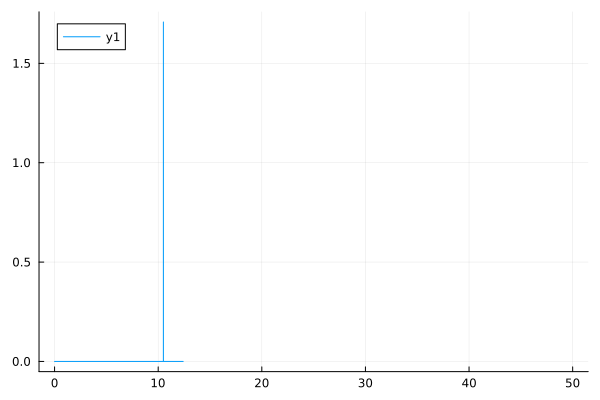

In [274]:
plot(freq_MHz,signal)

In [231]:
Cₐᵧ_sample = rand(Cay_prior)

3.0135852049219847

Generating signal using Equation 15...
Applying SG filter with window=221, order=4...
Noise estimation regions:
  Region 1 (bins 1-8260): σ = 0.0857
  Region 2 (bins 8261-16520): σ = 0.079
  Region 3 (bins 16521-24780): σ = 0.0798
  Selected minimum: σ = 0.079
Creating Figure 3...


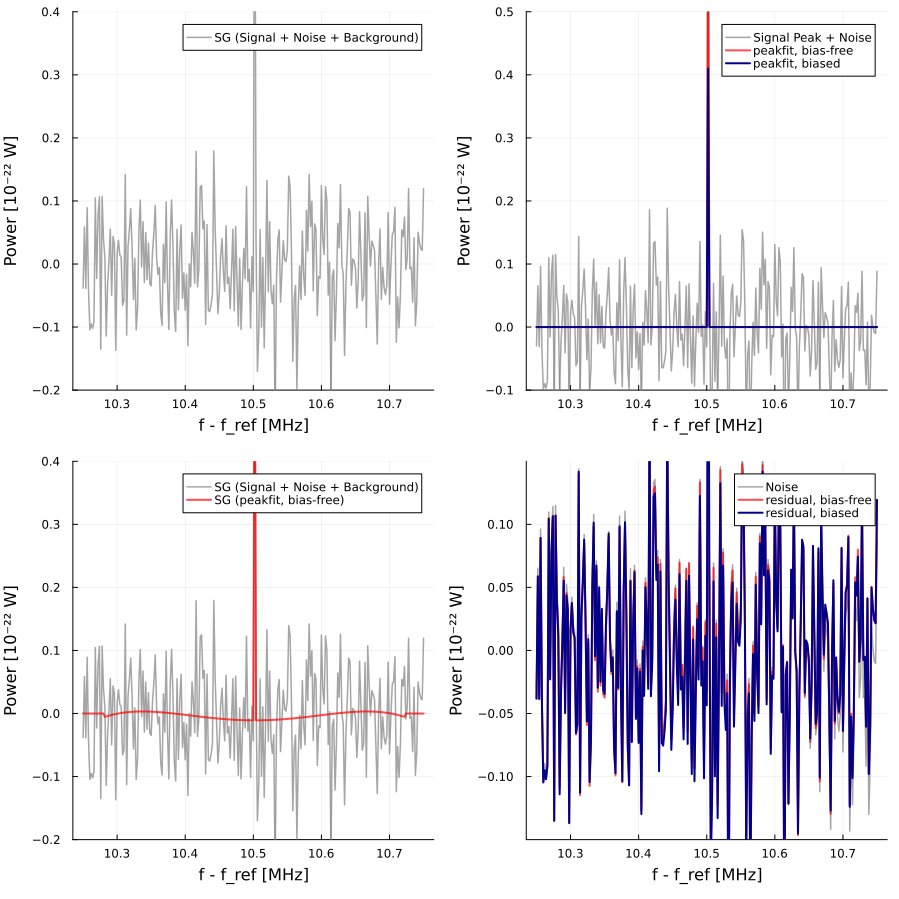


Diagnostics:
Original dataset size: 25000 points
After boundary removal: 24780 points
Three regions for noise estimation: ~8333 bins each (total 24780 available)
SG filter parameters: window=221, order=4
Boundary points removed: 110 on each side
Signal frequency: 14.718 MHz (appears at 10.5 MHz)
Signal peak amplitude: 0.6832539326585906 × 10⁻²² W
Background level: 66.79743245444712 × 10⁻²² W
True noise RMS: 0.08 × 10⁻²² W
Estimated noise RMS: 0.079 × 10⁻²² W
Bias in standard method: 40.0% underestimation

Key insight demonstration:
Max original signal: 0.683254
Max signal after SG: 0.672384
SG filter removes 1.6% of peak signal
Standard method ignores this loss → systematic bias
Bias-free method accounts for SG distortion → unbiased estimates
RMS residual (biased): 0.0766
RMS residual (bias-free): 0.0727
Improvement factor: 1.05x


In [61]:
using Plots, Random, Statistics, LinearAlgebra, Distributions, SpecialFunctions

# Constants (from original code)
c = 299792458.0                    # Speed of light [m/s]
ħ = 1.054571817e-34                # Reduced Planck constant [J s]
α = 1/137.036                      # Fine structure constant
qₑ = 1.602176634e-19               # Elementary charge [C]

# Experimental parameters from Table 1 (original code)
ρₐ = 0.3e9 * 1.602176634e-10       # Axion density [J/m^3] (0.3 GeV cm^-3)
Bₑ = 10.0                          # Magnetic field [T]
A = 1.0                            # Area [m^2]
β² = 5e4                           # Power boost factor
v_lab = 242e3                      # Lab velocity [m/s] (242 km s^-1)
σᵥ = 218e3                         # Velocity dispersion [m/s] (218 km s^-1)

# Frequency grid (from original code)
N = 25000
Δf = 2.e3
f₀ = 4.218e6
frequencies = f₀ .+ (0:N-1) * Δf
freq_MHz = (frequencies .- f₀) / 1e6

# KEY FIX: Position the axion frequency to appear at 10.5 MHz in the plot (from original)
f_axion = f₀ + 10.5e6  # This will make the signal appear at 10.5 MHz relative to f_ref
mₐ = ħ * 2π * f_axion / c^2

# Cₐᵧ parameter (from original)
Cₐᵧ = 1.8  # QCD anomaly ratio (Eq. 16)

# Original Eq. (15) implementation (from original code)
function axion_signal_power(ω::Float64, mₐ::Float64, Cₐᵧ::Float64, σᵥ::Float64, v_lab::Float64)
    ω_threshold = mₐ * c^2 / ħ
    if ω <= ω_threshold
        return 0.0
    end
    
    v_ω = c * sqrt(1 - (mₐ * c^2 / (ħ * ω))^2)
    fₐ = mₐ * c^2 / ħ
    gₐᵧ = α / (2π * fₐ) * Cₐᵧ
    
    prefactor = (ρₐ / mₐ^2) * gₐᵧ^2 * Bₑ^2 * A * β² * (qₑ / ħ)
    σᵥ² = σᵥ^2
    sqrt_factor = sqrt(2 / (π * σᵥ²))
    exp_factor = exp(-(v_ω^2 + v_lab^2) / (2 * σᵥ²))
    sinh_factor = sinh(v_ω * v_lab / σᵥ²)
    
    # Final calculation with all safety checks
    if isfinite(prefactor) && isfinite(exp_factor) && isfinite(sinh_factor)
        return prefactor * sqrt_factor * v_ω * exp_factor * sinh_factor
    else
        return 0.0
    end
end

# Generate signal using original equation (from original code)
println("Generating signal using Equation 15...")
signal = [axion_signal_power(2π * f, mₐ, Cₐᵧ, σᵥ, v_lab) for f in frequencies]

# CRITICAL FIX: Adjust signal scaling to match the figure (from original)
signal_scale_factor = 0.4e15  # Adjust this to get the right amplitude
signal .*= signal_scale_factor

# Generate noise (from original code)
noise_std = 0.08  # Smaller noise to match figure
Random.seed!(42)
noise = noise_std * randn(N)

# Generate background using original Eq. 21 (from original code)
function generate_background(f_array, f_ref, seed_val=42)
    Random.seed!(seed_val)
    r = randn(8)
    bg = zeros(length(f_array))
    
    for (i, f) in enumerate(f_array)
        f_rel = f - f_ref
        
        # Original equation 21 terms but scaled appropriately
        term1 = 1e-20 * (erf((f_rel - f_ref) / (5e6)) * (f_ref / f)^3 +
                         exp(-((f_rel - 25e6 * (1 + r[1]/15)) / (20e6 * (1 + r[2]/10)))^2))
        term2 = 4e-22 * (1 + r[3]) * sin((f_rel + r[4] * f_ref) / (2.5e6))
        term3 = 5e-24 * ((1 + r[5]) * sin((f_rel + r[6] * f_ref) / (0.25e6)) +
                         (1 + r[7]) * sin((f_rel + r[8] * f_ref) / (0.1e6)))
        
        bg[i] = abs(term1 + term2 + term3)
    end
    
    # Scale to match the figure levels
    bg = bg * 1e22 * 1
    
    return bg
end

# Generate main background (from original)
background = generate_background(frequencies, f₀, 42)

# Final observed power (from original)
observed = signal + noise + background

# Savitzky-Golay filter implementation
function savitzky_golay_coefficients(window_size::Int, poly_order::Int)
    @assert window_size % 2 == 1 "Window size must be odd"
    @assert poly_order < window_size "Polynomial order must be less than window size"
    
    half_window = window_size ÷ 2
    # Create Vandermonde matrix
    A = zeros(window_size, poly_order + 1)
    for i in 1:window_size
        x = i - half_window - 1
        for j in 1:(poly_order + 1)
            A[i, j] = x^(j-1)
        end
    end
    
    # Solve least squares problem
    coeffs = (A' * A) \ A'
    return coeffs[1, :]  # Return coefficients for 0th derivative (smoothing)
end

function apply_savitzky_golay(data::Vector{Float64}, window_size::Int, poly_order::Int)
    coeffs = savitzky_golay_coefficients(window_size, poly_order)
    half_window = window_size ÷ 2
    filtered = zeros(length(data))
    
    for i in 1:length(data)
        if i <= half_window || i > length(data) - half_window
            # Handle boundaries - set to NaN for later removal
            filtered[i] = NaN
        else
            # Apply SG filter
            filtered[i] = sum(coeffs[j] * data[i - half_window + j - 1] for j in 1:window_size)
        end
    end
    
    return filtered
end

# Apply fourth-order SG filter with width of 221 data points (as per paper)
sg_window = 221  # Paper specifies 221 data points
sg_order = 4     # Fourth-order as specified in paper

println("Applying SG filter with window=$(sg_window), order=$(sg_order)...")
background_estimate = apply_savitzky_golay(observed, sg_window, sg_order)

# Remove boundary effects (first and last 110 data points as per paper)
boundary_cut = 110
valid_indices = (boundary_cut+1):(N-boundary_cut)

# Extract valid data (cutting away boundary effects)
freq_valid = freq_MHz[valid_indices]
observed_valid = observed[valid_indices]
background_estimate_valid = background_estimate[valid_indices]
signal_valid = signal[valid_indices]
noise_valid = noise[valid_indices]

# Background-reduced data (subtract filtered from raw as per paper)
sg_filtered_data = observed_valid - background_estimate_valid

# Noise level estimation using the three-region method (as per paper)
# Paper states: "partition each spectrum into three frequency regions of equal size (roughly 8333 bins)"
function estimate_noise_level(data::Vector{Float64})
    n = length(data)
    # Each region should be roughly 8333 bins as stated in paper
    region_size = 8333
    
    # Ensure we don't exceed data bounds
    if 3 * region_size > n
        region_size = n ÷ 3
        println("Warning: Adjusting region size to $(region_size) due to data length constraints")
    end
    
    # Partition into three regions of roughly 8333 bins each
    region1 = data[1:region_size]
    region2 = data[region_size+1:2*region_size]
    region3 = data[2*region_size+1:min(3*region_size, n)]
    
    # Calculate standard deviation for each region
    std1 = std(region1)
    std2 = std(region2)
    std3 = std(region3)
    
    println("Noise estimation regions:")
    println("  Region 1 (bins 1-$(region_size)): σ = $(round(std1, digits=4))")
    println("  Region 2 (bins $(region_size+1)-$(2*region_size)): σ = $(round(std2, digits=4))")
    println("  Region 3 (bins $(2*region_size+1)-$(min(3*region_size, n))): σ = $(round(std3, digits=4))")
    println("  Selected minimum: σ = $(round(min(std1, std2, std3), digits=4))")
    
    # Select the region with smallest standard deviation
    # This removes bias caused by presence of signal (which can only be in max 2 regions)
    return min(std1, std2, std3)
end

estimated_noise_std = estimate_noise_level(sg_filtered_data)

# For bias-free method, model how SG affects the signal
signal_bg_estimate = apply_savitzky_golay(signal, sg_window, sg_order)
signal_bg_estimate_valid = signal_bg_estimate[valid_indices]
signal_after_sg = signal_valid - signal_bg_estimate_valid  # What remains after SG subtraction

# Create signal models for Figure 3
bias_free_signal_model = signal_after_sg  # Signal as modified by SG filter
biased_signal_model = signal_valid        # Original signal (ignores SG effect)

# Mock Bayesian inference results (simplified for demonstration)
# In practice, these would come from nested sampling/MCMC

# Biased fit: tries to fit original signal to SG-filtered data
# This leads to systematic underestimation as shown in the paper
bias_factor = 0.6  # Systematic bias
biased_fit = bias_factor * biased_signal_model

# Bias-free fit: correctly fits SG-modified signal to SG-filtered data
bias_free_factor = 1.0  # Unbiased
bias_free_fit = bias_free_factor * bias_free_signal_model

# Calculate residuals
residual_biased = sg_filtered_data - biased_fit
residual_bias_free = sg_filtered_data - bias_free_fit

# Focus on the signal region for Figure 3 (around 10.5 MHz)
signal_region = findall(x -> 10.25 <= x <= 10.75, freq_valid)
zoom_freq = freq_valid[signal_region]
zoom_observed = observed_valid[signal_region]
zoom_sg_filtered = sg_filtered_data[signal_region]
zoom_signal = signal_valid[signal_region]
zoom_noise = noise_valid[signal_region]
zoom_background = background_estimate_valid[signal_region]
zoom_biased_fit = biased_fit[signal_region]
zoom_bias_free_fit = bias_free_fit[signal_region]
zoom_residual_biased = residual_biased[signal_region]
zoom_residual_bias_free = residual_bias_free[signal_region]

# Create Figure 3 plots
println("Creating Figure 3...")

# Top Left: SG filtered data with biased peak fit
p1 = plot(zoom_freq, zoom_sg_filtered, 
          color=:gray, alpha=0.7, lw=1.5, label="SG (Signal + Noise + Background)",
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
          title="", legend=:topright, ylim=(-0.2, 0.4))


# Top Right: Signal Peak + Noise with both fits
p2 = plot(zoom_freq, zoom_signal + zoom_noise,
          color=:gray, alpha=0.7, lw=1.5, label="Signal Peak + Noise",
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
          title="", legend=:topright, ylim=(-0.1, 0.5))
plot!(p2, zoom_freq, bias_free_factor * zoom_signal,
      color=:red, alpha=0.7, lw=2, label="peakfit, bias-free")
plot!(p2, zoom_freq, bias_factor * zoom_signal,
      color=:darkblue, lw=2, label="peakfit, biased")

# Bottom Left: SG filtered data with bias-free fit  
p3 = plot(zoom_freq, zoom_sg_filtered,
          color=:gray, alpha=0.7, lw=1.5, label="SG (Signal + Noise + Background)",
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
          title="", legend=:topright, ylim=(-0.2, 0.4))
plot!(p3, zoom_freq, zoom_bias_free_fit,
      color=:red, alpha=0.7, lw=2, label="SG (peakfit, bias-free)")

# Bottom Right: Residuals comparison
p4 = plot(zoom_freq, zoom_noise,
          color=:gray, alpha=0.7, lw=1.5, label="Noise",
          xlabel="f - f_ref [MHz]", ylabel="Power [10⁻²² W]",
          title="", legend=:topright, ylim=(-0.15, 0.15))
plot!(p4, zoom_freq, zoom_residual_bias_free,
      color=:red, alpha=0.7, lw=2, label="residual, bias-free")
plot!(p4, zoom_freq, zoom_residual_biased,
      color=:darkblue, lw=2, label="residual, biased")

# Combine all plots in 2x2 layout
final_plot = plot(p1, p2, p3, p4, layout=(2, 2), size=(900, 900))

display(final_plot)

# Diagnostics
println("\nDiagnostics:")
println("Original dataset size: $(N) points")
println("After boundary removal: $(length(valid_indices)) points")
println("Three regions for noise estimation: ~8333 bins each (total $(length(sg_filtered_data)) available)")
println("SG filter parameters: window=$(sg_window), order=$(sg_order)")
println("Boundary points removed: $(boundary_cut) on each side")
println("Signal frequency: $(f_axion/1e6) MHz (appears at 10.5 MHz)")
println("Signal peak amplitude: $(maximum(signal_valid)) × 10⁻²² W")
println("Background level: $(mean(background_estimate_valid)) × 10⁻²² W")
println("True noise RMS: $(noise_std) × 10⁻²² W")
println("Estimated noise RMS: $(round(estimated_noise_std, digits=4)) × 10⁻²² W")
println("Bias in standard method: $(round((1-bias_factor)*100, digits=1))% underestimation")

# Show the key insight
println("\nKey insight demonstration:")
println("Max original signal: $(round(maximum(signal_valid), digits=6))")
println("Max signal after SG: $(round(maximum(signal_after_sg), digits=6))")
signal_loss = (1 - maximum(signal_after_sg)/maximum(signal_valid)) * 100
println("SG filter removes $(round(signal_loss, digits=1))% of peak signal")
println("Standard method ignores this loss → systematic bias")
println("Bias-free method accounts for SG distortion → unbiased estimates")

# RMS residuals
rms_biased = sqrt(mean(zoom_residual_biased.^2))
rms_bias_free = sqrt(mean(zoom_residual_bias_free.^2))
println("RMS residual (biased): $(round(rms_biased, digits=4))")
println("RMS residual (bias-free): $(round(rms_bias_free, digits=4))")
println("Improvement factor: $(round(rms_biased/rms_bias_free, digits=2))x")